In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [10]:
features_final = pd.read_csv("../data/extracted_features_mean.csv")

In [11]:
train_groups = ['a', 'b', 'c', 'd']
train_features = features_final[features_final['group_id'].isin(train_groups)]

In [12]:
feature_cols = ["Asymmetry", "Compactness", "Convexity", "Multicolor", "red_pixels", "blue_pixels", "mean_red", "mean_blue", "Entropy", "Hue_Var", "Sat_Var", "Val_Var"]

train_df = train_features[feature_cols + ["Class"]].copy()
train_df["label"] = train_df["Class"].astype(int)
train_df = train_df.drop(columns=["Class"])

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features from the target
X = train_df.drop(columns=['label'])
y = train_df['label']

# 2. Split into Training (80%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 3. Initialize the Scaler
scaler = StandardScaler()

# 4. Fit and Transform the Training data(calculates the mean and standard deviation of training features.)
X_train_scaled = scaler.fit_transform(X_train)

# 5. Transform the Validation data (We use the training mean/std to scale the validation set)
X_val_scaled = scaler.transform(X_val)


In [15]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

#random forest
# 1. Define your different feature combinations
feature_packs = {
    "Shape_Only": ["Asymmetry", "Convexity", "mean_red", "Entropy"],
    "Color_Texture": ["Multicolor", "Hue_Var", "Entropy"],
    "Top_3_Importance": ["mean_blue", "Convexity", "mean_red"],
    "Hybrid Mix": ["Asymmetry", "Entropy", "mean_blue", "Convexity"],
    "Final_maybe": ["mean_blue", "mean_red", "Entropy", "Multicolor", "Convexity"],
    "all_features": ["Asymmetry", "Compactness", "Convexity", "Multicolor", "red_pixels", "blue_pixels", "mean_red", "mean_blue", "Entropy", "Hue_Var", "Sat_Var", "Val_Var"]
}

# 2. Loop through each combination to find the best one
for pack_name, cols in feature_packs.items():
    print(f"\n--- Testing Combination: {pack_name} ---")
    
    # Prepare and Scale data for this specific combination
    X_train_sub = X_train[cols]
    X_val_sub = X_val[cols]
    
    scaler = StandardScaler()
    X_train_scaled_sub = scaler.fit_transform(X_train_sub)
    X_val_scaled_sub = scaler.transform(X_val_sub)
    
    n_est_metrics = {"train":[], "val":[]}
    print(f"Evaluating n_estimators:")
    n_estimators = [1, 5, 10, 50, 100]
    for n in n_estimators:
        # We use max_depth=3 as a stable baseline for testing n_estimators
        random_forest = RandomForestClassifier(n_estimators=n, max_depth=3, random_state=42)
        random_forest.fit(X_train_scaled_sub, y_train)

        train_acc = random_forest.score(X_train_scaled_sub, y_train)
        val_acc = random_forest.score(X_val_scaled_sub, y_val)

        n_est_metrics["train"].append(train_acc)
        n_est_metrics["val"].append(val_acc)
        print(f"n_estimators={n:3} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")

    max_depth_metrics = {"train":[], "val":[]}
    print(f"Evaluating max_depth:")
    depths = [1, 3, 5, 7, 10, None]
    for depth in depths:
        # We use the best n_estimators (usually 100) to test depth
        random_forest = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42) 
        random_forest.fit(X_train_scaled_sub, y_train)

        train_acc = random_forest.score(X_train_scaled_sub, y_train)
        val_acc = random_forest.score(X_val_scaled_sub, y_val)

        max_depth_metrics["train"].append(train_acc)
        max_depth_metrics["val"].append(val_acc)
        print(f"max_depth={str(depth):4} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")





--- Testing Combination: Shape_Only ---
Evaluating n_estimators:
n_estimators=  1 - train_acc: 0.543 - val_acc: 0.538
n_estimators=  5 - train_acc: 0.578 - val_acc: 0.520
n_estimators= 10 - train_acc: 0.596 - val_acc: 0.498
n_estimators= 50 - train_acc: 0.657 - val_acc: 0.527
n_estimators=100 - train_acc: 0.661 - val_acc: 0.560
Evaluating max_depth:
max_depth=1    - train_acc: 0.532 - val_acc: 0.545
max_depth=3    - train_acc: 0.661 - val_acc: 0.560
max_depth=5    - train_acc: 0.760 - val_acc: 0.523
max_depth=7    - train_acc: 0.866 - val_acc: 0.538
max_depth=10   - train_acc: 0.981 - val_acc: 0.531
max_depth=None - train_acc: 1.000 - val_acc: 0.563

--- Testing Combination: Color_Texture ---
Evaluating n_estimators:
n_estimators=  1 - train_acc: 0.531 - val_acc: 0.523
n_estimators=  5 - train_acc: 0.573 - val_acc: 0.505
n_estimators= 10 - train_acc: 0.576 - val_acc: 0.505
n_estimators= 50 - train_acc: 0.582 - val_acc: 0.516
n_estimators=100 - train_acc: 0.579 - val_acc: 0.527
Evaluat

Final Model AUC: 0.5127


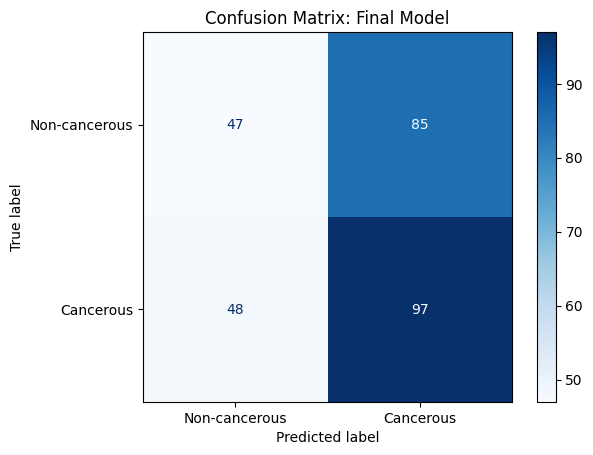

In [16]:
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. SET YOUR BEST SETTINGS HERE
# Replace with the best combination and numbers you found
best_cols = ["mean_blue", "mean_red", "Entropy", "Multicolor", "Convexity"]
best_n = 50
best_depth = 5

# 2. Prepare the data with your winning features
X_train_final = X_train[best_cols]
X_val_final = X_val[best_cols]

scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_final_scaled = scaler.transform(X_val_final)

# 3. Train the Final Model
final_model = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth, random_state=42)
final_model.fit(X_train_final_scaled, y_train)

# 4. Get PROBABILITIES and AUC
# [:, 1] gets the probability of the image being a Lesion (Class 1)
probs = final_model.predict_proba(X_val_final_scaled)[:, 1]
auc_score = roc_auc_score(y_val, probs)

# 5. Get PREDICTIONS (0 or 1) and Confusion Matrix
#predictions = final_model.predict(X_val_final_scaled)
#cm = confusion_matrix(y_val, predictions)

pos_class_probs = final_model.predict_proba(X_val_final_scaled)[:, 1]
 
# 2. Define your threshold (e.g., 0.3)
threshold = 0.5
 
# 3. Create new class predictions based on the custom threshold
# If prob >= threshold, classify as 1, else 0
custom_predictions = (pos_class_probs >= threshold).astype(int)
 
# 4. Now generate the confusion matrix with your custom labels
from sklearn.metrics import confusion_matrix
cm_custom = confusion_matrix(y_val, custom_predictions)

# --- DISPLAY RESULTS ---
print(f"Final Model AUC: {auc_score:.4f}")

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=["Non-cancerous", "Cancerous"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Final Model")
plt.show()


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# 1. Loop through each combination
for pack_name, cols in feature_packs.items():
    print(f"\n--- Logistic Regression: {pack_name} ---")
    
    # Scale only the features in this pack
    scaler = StandardScaler()
    X_train_scaled_sub = scaler.fit_transform(X_train[cols])
    X_val_scaled_sub = scaler.transform(X_val[cols])
    
    # 2. Train the model
    # Using 'balanced' to help with class overlap
    lr_model = LogisticRegression(random_state=42, class_weight='balanced')
    lr_model.fit(X_train_scaled_sub, y_train)
    
    # 3. Get probabilities and apply threshold
    threshold = 0.5
    val_proba = lr_model.predict_proba(X_val_scaled_sub)[:, 1]
    val_pred = (val_proba >= threshold).astype(int)
    
    # 4. Print Validation Results
    acc = accuracy_score(y_val, val_pred)
    auc = roc_auc_score(y_val, val_proba)
    
    print(f"Validation Accuracy: {acc:.3f}")
    print(f"Validation AUC:      {auc:.3f}")



--- Logistic Regression: Shape_Only ---
Validation Accuracy: 0.509
Validation AUC:      0.513

--- Logistic Regression: Color_Texture ---
Validation Accuracy: 0.495
Validation AUC:      0.508

--- Logistic Regression: Top_3_Importance ---
Validation Accuracy: 0.527
Validation AUC:      0.519

--- Logistic Regression: Hybrid Mix ---
Validation Accuracy: 0.538
Validation AUC:      0.528

--- Logistic Regression: Final_maybe ---
Validation Accuracy: 0.527
Validation AUC:      0.521

--- Logistic Regression: all_features ---
Validation Accuracy: 0.473
Validation AUC:      0.472


Final Logistic Regression AUC: 0.5422


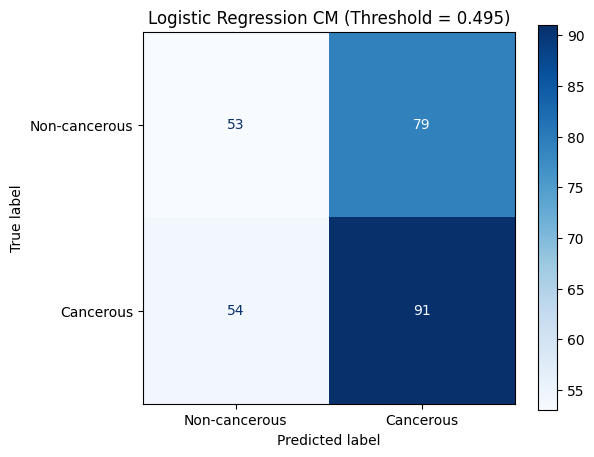

In [18]:
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. SET YOUR BEST SETTINGS HERE
# Replace with the best combination and numbers you found
best_cols = ["Asymmetry", "Convexity", "Entropy"]

# 2. Prepare the data with your winning features
X_train_final = X_train[best_cols]
X_val_final = X_val[best_cols]

scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_final_scaled = scaler.transform(X_val_final)

# 1. SETUP THE FINAL LOGISTIC REGRESSION MODEL
# Use the best_weight found during your optimization loop
# Example: best_weight = {0: 1, 1: 5.5} or 'balanced'
final_lr_model = LogisticRegression(
    class_weight='balanced', 
    random_state=42, 
    max_iter=1000
)
# 2. Train the model
final_lr_model.fit(X_train_final_scaled, y_train)
# 3. GET PROBABILITIES (The "Confidence" scores)
# [:, 1] extracts the probability of being "Cancerous"
pos_class_probs = final_lr_model.predict_proba(X_val_final_scaled)[:, 1]

# 4. CALCULATE THE AUC
auc_score = roc_auc_score(y_val, pos_class_probs)

# 5. APPLY CUSTOM THRESHOLD
# You can lower this (e.g., 0.3) if you want to catch more lesions
threshold = 0.495
custom_predictions = (pos_class_probs >= threshold).astype(int)

# 6. GENERATE CONFUSION MATRIX
cm_custom = confusion_matrix(y_val, custom_predictions)

# --- DISPLAY RESULTS ---
print(f"Final Logistic Regression AUC: {auc_score:.4f}")

# Plotting the results
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_custom, 
    display_labels=["Non-cancerous", "Cancerous"]
)
disp.plot(cmap="Blues", ax=ax)
plt.title(f"Logistic Regression CM (Threshold = {threshold})")
plt.show()


Validation ROC AUC Score: 0.5553


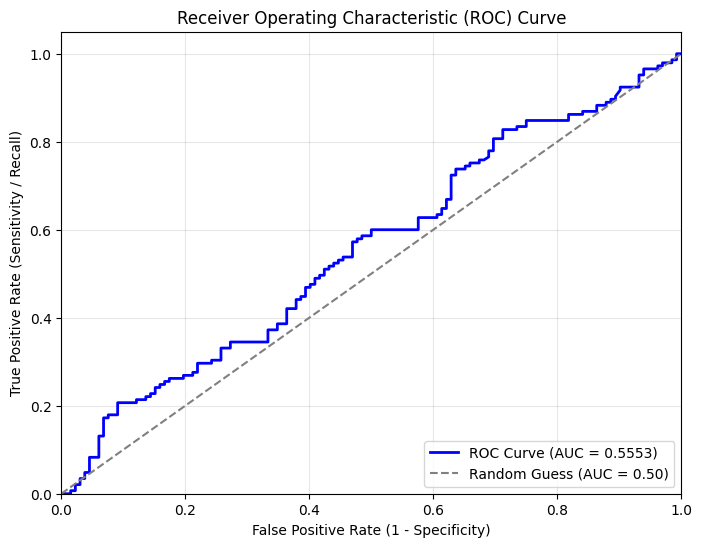

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get the predicted probabilities for the positive class (Class 1, "Cancerous")

# final_model is your trained RandomForest, X_val_scaled is your scaled validation features

y_val_probs = final_model.predict_proba(X_val_final_scaled)[:, 1]

# 2. Calculate False Positive Rate, True Positive Rate, and Thresholds

fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)

# 3. Calculate the overall AUC Score

auc_score = roc_auc_score(y_val, y_val_probs)

print(f"Validation ROC AUC Score: {auc_score:.4f}")

# 4. Plot the ROC Curve

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])

plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity / Recall)')

plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)

plt.show()
 

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Define the range of k values you want to test
k_values = [1, 3, 5, 7, 9, 11, 13, 15]

# 2. Loop through each feature combination
for pack_name, cols in feature_packs.items():
    print(f"\n--- Testing kNN: {pack_name} ---")
    
    # Scale only the features in this pack
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train[cols])
    X_va_sc = scaler.transform(X_val[cols])
    
    print(f"{'k-Value':<10} | {'Train Acc':<10} | {'Val Acc':<10} | {'Val AUC':<10}")
    print("-" * 50)

    # 3. Loop through different k values for this specific pack
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr_sc, y_train)
        
        # Calculate Scores
        t_acc = knn.score(X_tr_sc, y_train)
        v_acc = knn.score(X_va_sc, y_val)
        
        # Get AUC (using probabilities)
        v_probs = knn.predict_proba(X_va_sc)[:, 1]
        v_auc = roc_auc_score(y_val, v_probs)
        
        print(f"k={k:<8} | {t_acc:.3f}      | {v_acc:.3f}    | {v_auc:.3f}")



--- Testing kNN: Shape_Only ---
k-Value    | Train Acc  | Val Acc    | Val AUC   
--------------------------------------------------
k=1        | 1.000      | 0.542    | 0.541
k=3        | 0.766      | 0.538    | 0.548
k=5        | 0.685      | 0.570    | 0.553
k=7        | 0.643      | 0.549    | 0.535
k=9        | 0.631      | 0.509    | 0.509
k=11       | 0.621      | 0.513    | 0.526
k=13       | 0.616      | 0.502    | 0.515
k=15       | 0.611      | 0.509    | 0.507

--- Testing kNN: Color_Texture ---
k-Value    | Train Acc  | Val Acc    | Val AUC   
--------------------------------------------------
k=1        | 1.000      | 0.444    | 0.445
k=3        | 0.750      | 0.480    | 0.479
k=5        | 0.670      | 0.473    | 0.463
k=7        | 0.655      | 0.477    | 0.462
k=9        | 0.639      | 0.466    | 0.446
k=11       | 0.640      | 0.502    | 0.457
k=13       | 0.623      | 0.455    | 0.439
k=15       | 0.593      | 0.466    | 0.446

--- Testing kNN: Top_3_Importance ---
k-

Final kNN (k=11) AUC: 0.5167
Chosen Threshold: 0.5455


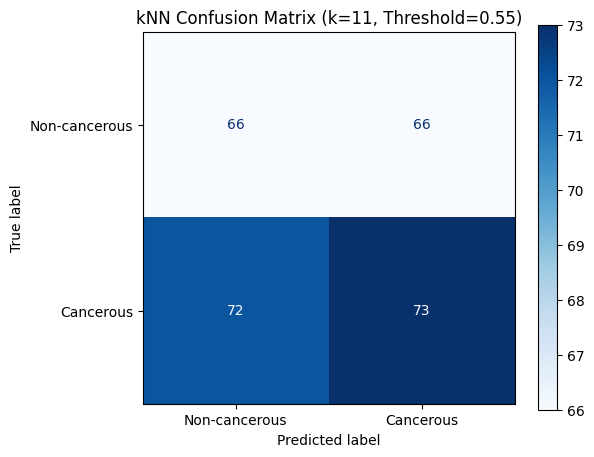

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. SETUP THE FINAL kNN MODEL
# Replace with the k and features that gave you the highest Val AUC
best_k = 11  # Example
final_cols = ["Asymmetry", "Entropy", "Convexity"]

# 2. SCALE THE DATA FOR THIS SPECIFIC PACK
# Use your training and validation splits
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train[final_cols])
X_val_final_scaled = scaler.transform(X_val[final_cols])

# 3. TRAIN THE MODEL
final_knn_model = KNeighborsClassifier(n_neighbors=best_k)
final_knn_model.fit(X_train_final_scaled, y_train)

# 4. GET PROBABILITIES AND AUC
# [:, 1] gets the probability of the image being a Lesion (Class 1)
knn_probs = final_knn_model.predict_proba(X_val_final_scaled)[:, 1]
auc_score = roc_auc_score(y_val, knn_probs)

# 5. FIND THE THRESHOLD FOR YOUR GOAL (0.5, 0.6)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, knn_probs)

# Find the threshold closest to your chosen point on the ROC curve
distances = np.sqrt((fpr - 0.5)**2 + (tpr - 0.6)**2)
chosen_threshold = thresholds[np.argmin(distances)]

# 6. APPLY CUSTOM THRESHOLD
custom_predictions = (knn_probs >= chosen_threshold).astype(int)
cm = confusion_matrix(y_val, custom_predictions)

# --- DISPLAY RESULTS ---
print(f"Final kNN (k={best_k}) AUC: {auc_score:.4f}")
print(f"Chosen Threshold: {chosen_threshold:.4f}")

# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Non-cancerous", "Cancerous"]
)
disp.plot(cmap="Blues", ax=ax)
plt.title(f"kNN Confusion Matrix (k={best_k}, Threshold={chosen_threshold:.2f})")
plt.show()


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Define the depths you want to test
# We include 'None' to see what happens when the tree is unlimited
depths = [1, 2, 3, 4, 5, 7, 10, 20, None]

for pack_name, cols in feature_packs.items():
    print(f"\n--- Testing Decision Tree: {pack_name} ---")
    
    # Subset and Scale
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train[cols])
    X_va_sc = scaler.transform(X_val[cols])
    
    print(f"{'Max Depth':<10} | {'Train Acc':<10} | {'Val Acc':<10} | {'Val AUC':<10}")
    print("-" * 55)

    # 2. Loop through different depths
    for d in depths:
        # We set random_state=42 so the results are consistent
        dt = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
        dt.fit(X_tr_sc, y_train)
        
        # Calculate Scores
        t_acc = dt.score(X_tr_sc, y_train)
        v_acc = dt.score(X_va_sc, y_val)
        
        # Get AUC (using probabilities)
        v_probs = dt.predict_proba(X_va_sc)[:, 1]
        v_auc = roc_auc_score(y_val, v_probs)
        
        print(f"depth={str(d):<6} | {t_acc:.3f}      | {v_acc:.3f}    | {v_auc:.3f}")



--- Testing Decision Tree: Shape_Only ---
Max Depth  | Train Acc  | Val Acc    | Val AUC   
-------------------------------------------------------
depth=1      | 0.540      | 0.538    | 0.537
depth=2      | 0.549      | 0.527    | 0.521
depth=3      | 0.552      | 0.527    | 0.520
depth=4      | 0.577      | 0.552    | 0.562
depth=5      | 0.600      | 0.560    | 0.580
depth=7      | 0.663      | 0.523    | 0.543
depth=10     | 0.763      | 0.588    | 0.614
depth=20     | 0.999      | 0.552    | 0.553
depth=None   | 1.000      | 0.552    | 0.553

--- Testing Decision Tree: Color_Texture ---
Max Depth  | Train Acc  | Val Acc    | Val AUC   
-------------------------------------------------------
depth=1      | 0.539      | 0.523    | 0.503
depth=2      | 0.510      | 0.473    | 0.494
depth=3      | 0.521      | 0.462    | 0.465
depth=4      | 0.528      | 0.469    | 0.479
depth=5      | 0.566      | 0.487    | 0.472
depth=7      | 0.606      | 0.495    | 0.502
depth=10     | 0.678    

Final Decision Tree (depth=5) AUC: 0.5801
Chosen Threshold: 0.5272


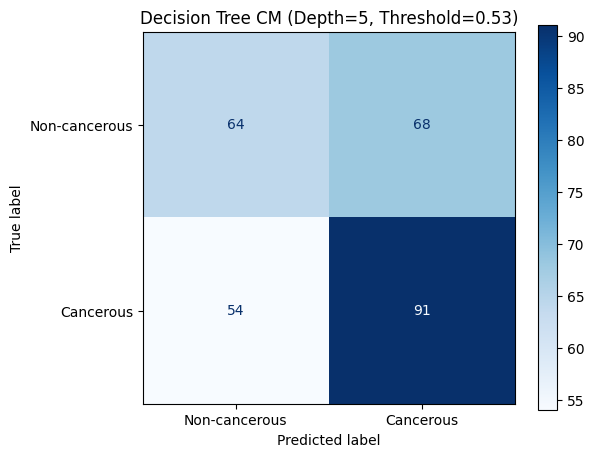

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. SETUP THE FINAL DECISION TREE
# Replace with your winning depth and features
best_depth = 5  # Example from your logs
final_cols = ["Asymmetry", "Entropy", "mean_red", "Convexity"]

# 2. SCALE THE DATA FOR THIS SPECIFIC PACK
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train[final_cols])
X_val_final_scaled = scaler.transform(X_val[final_cols])

# 3. TRAIN THE MODEL
# Using 'balanced' ensures the tree doesn't ignore the rare lesion class
final_dt_model = DecisionTreeClassifier(
    max_depth=best_depth, 
    class_weight='balanced', 
    random_state=42
)
final_dt_model.fit(X_train_final_scaled, y_train)

# 4. GET PROBABILITIES AND AUC
dt_probs = final_dt_model.predict_proba(X_val_final_scaled)[:, 1]
auc_score = roc_auc_score(y_val, dt_probs)

# 5. FIND THE THRESHOLD FOR YOUR GOAL (0.5, 0.6)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, dt_probs)

# Find threshold closest to the (0.5, 0.6) point
distances = np.sqrt((fpr - 0.5)**2 + (tpr - 0.6)**2)
chosen_threshold = thresholds[np.argmin(distances)]

# 6. APPLY CUSTOM THRESHOLD & CONFUSION MATRIX
custom_predictions = (dt_probs >= chosen_threshold).astype(int)
cm = confusion_matrix(y_val, custom_predictions)

# --- DISPLAY RESULTS ---
print(f"Final Decision Tree (depth={best_depth}) AUC: {auc_score:.4f}")
print(f"Chosen Threshold: {chosen_threshold:.4f}")

# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Non-cancerous", "Cancerous"]
)
disp.plot(cmap="Blues", ax=ax)
plt.title(f"Decision Tree CM (Depth={best_depth}, Threshold={chosen_threshold:.2f})")
plt.show()



========== Fold 1 ==========
AUC: 0.4957

========== Fold 2 ==========
AUC: 0.4889

========== Fold 3 ==========
AUC: 0.5141

========== Fold 4 ==========
AUC: 0.4819

Decision Tree Cross-Validation
Fold AUCs: [0.49566653584510734, 0.4889381985535831, 0.5141260162601625, 0.4818888121546961]
Mean AUC: 0.49515489070338725
Std AUC: 0.011987508988395564


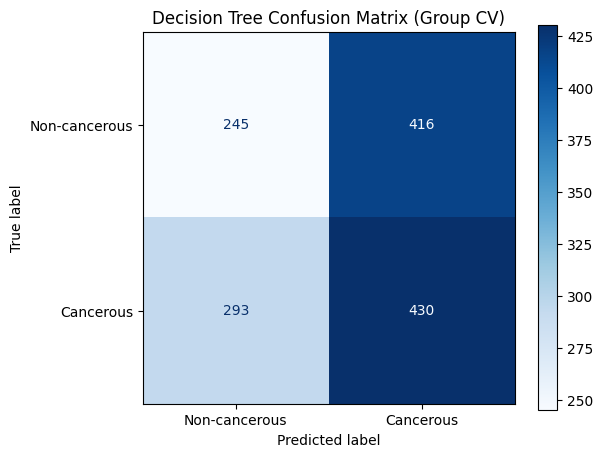

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------

features_final = pd.read_csv("../data/extracted_features_mean.csv")

train_groups = ['a', 'b', 'c', 'd']

train_features = features_final[
    features_final['group_id'].isin(train_groups)
]

# ---------------------------------------------------
# SELECT FEATURES
# ---------------------------------------------------

feature_cols = [
    "Asymmetry",
    "Entropy",
    "Convexity"
]

# Keep group_id for GroupKFold
train_df = train_features[
    feature_cols + ["Class", "group_id"]
].copy()

# Labels
train_df["label"] = train_df["Class"].astype(int)

# X, y, groups
X = train_df[feature_cols]

y = train_df["label"]

groups = train_df["group_id"]

# ---------------------------------------------------
# DECISION TREE PIPELINE
# ---------------------------------------------------

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

# ---------------------------------------------------
# GROUP-BASED CROSS VALIDATION
# ---------------------------------------------------

gkf = GroupKFold(n_splits=4)

auc_scores = []

all_true = []
all_probs = []
all_preds = []

# ---------------------------------------------------
# LOOP THROUGH FOLDS
# ---------------------------------------------------

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups)
):

    print(f"\n========== Fold {fold+1} ==========")

    # Split data
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # Train model
    pipeline.fit(X_train, y_train)

    # Predict probabilities
    probs = pipeline.predict_proba(X_val)[:, 1]

    # Convert probabilities to predictions
    preds = (probs >= 0.5).astype(int)

    # Calculate AUC
    auc = roc_auc_score(y_val, probs)

    auc_scores.append(auc)

    print(f"AUC: {auc:.4f}")

    # Store results
    all_true.extend(y_val)
    all_probs.extend(probs)
    all_preds.extend(preds)

# ---------------------------------------------------
# FINAL RESULTS
# ---------------------------------------------------

print("\n==============================")
print("Decision Tree Cross-Validation")
print("==============================")

print("Fold AUCs:", auc_scores)

print("Mean AUC:", np.mean(auc_scores))

print("Std AUC:", np.std(auc_scores))

# ---------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------
cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-cancerous", "Cancerous"]
)

disp.plot(cmap="Blues", ax=ax)

plt.title("Decision Tree Confusion Matrix (Group CV)")

plt.show()

